In [31]:
import pandas as pd
import os
import numpy as np
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt

# Load dataset

In [2]:
folder_path = r'../../../data/raw'
path_main = os.path.join(folder_path, 'all_stocks_5yr.csv')

df = pd.read_csv(path_main)
df['date'] = pd.to_datetime(df['date'])

# Aseguramos el orden cronológico para que el recorte de registros sea correcto
df = df.sort_values(['Name', 'date'])



In [3]:
df.head()

,date,open,high,low,close,volume,Name,adjusted_price
71611,2013-02-08,45.07,45.35,45.00,45.08,1824755,A,28.883968
71612,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,28.576422
71613,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,28.589230
71614,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,28.672525
71615,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,28.563612


In [4]:
df.shape

(619040, 8)

# Analize Data

In [5]:
def detect_missing_days_global_range(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["Name", "date"])

    nyse = mcal.get_calendar("NYSE")

    min_date = df["date"].min()
    max_date = df["date"].max()

    valid_days = nyse.valid_days(start_date=min_date, end_date=max_date).tz_localize(None)
    valid_set = set(valid_days)

    results = []

    for name, group in df.groupby("Name"):
        actual_days = set(pd.to_datetime(group["date"].unique()))

        missing_days = sorted(valid_set - actual_days)

        if missing_days:
            results.append({
                "Name": name,
                "num_missing": len(missing_days),
                "missing_days": missing_days
            })

    return pd.DataFrame(results)


gaps = detect_missing_days_global_range(df)

In [6]:
print(gaps)

    Name  num_missing                                       missing_days
0   ALLE          196  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
1   APTV         1215  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
2    BHF         1116  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
3   BHGE         1107  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
4    BMY            2         [2013-04-26 00:00:00, 2013-06-07 00:00:00]
5    CFG          409  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
6   COTY           86  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
7   CSRA          698  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
8    DHR           16  [2013-04-26 00:00:00, 2013-09-09 00:00:00, 201...
9   DWDP         1150  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
10   DXC         1044  [2013-02-08 00:00:00, 2013-02-11 00:00:00, 201...
11    ES           10  [2015-03-09 00:00:00, 2015-03-10 00:00:00, 201...
12  EVHC          962  [2013-02-08 00:00:00, 2013-0

In [7]:
gaps.shape

(35, 3)

# Prepare Data

## Drop missing values

In [8]:
stocks_to_delete = gaps[gaps["num_missing"] > 30]["Name"].tolist()
df_clean = df[~df["Name"].isin(stocks_to_delete)]
df_clean.shape

(599233, 8)

## Add missing days

In [14]:
def add_missing_from_gaps(df, gaps):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)

    existing = set(zip(df["Name"], df["date"]))

    new_rows = []

    for _, row in gaps.iterrows():
        name = row["Name"]
        missing_days = pd.to_datetime(row["missing_days"]).tz_localize(None)

        for d in missing_days:
            if (name, d) not in existing: 
                new_rows.append({
                    "date": d,
                    "open": None,
                    "high": None,
                    "low": None,
                    "close": None,
                    "volume": None,
                    "adjusted_price": None,
                    "Name": name
                })

    missing_df = pd.DataFrame(new_rows)

    result = pd.concat([df, missing_df], ignore_index=True)
    result = result.sort_values(["Name", "date"]).reset_index(drop=True)

    return result

In [15]:
df_clean = add_missing_from_gaps(df_clean,gaps)
df_clean.shape

(615988, 8)

In [16]:
cols = ["open", "high", "low", "close", "volume", "adjusted_price"]

df_clean = df_clean.sort_values(["Name", "date"])
df_clean[cols] = df_clean.groupby("Name")[cols].ffill().bfill()

In [17]:
df_clean.head()

,date,open,high,low,close,volume,Name,adjusted_price
0,2013-02-08,45.07,45.35,45.0,45.08,1824755,A,28.883968
1,2013-02-11,45.17,45.18,44.45,44.6,2915405,A,28.576422
2,2013-02-12,44.81,44.95,44.5,44.62,2373731,A,28.589230
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,28.672525
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,28.563612


<Axes: title={'center': 'Valores nulos por columna'}>

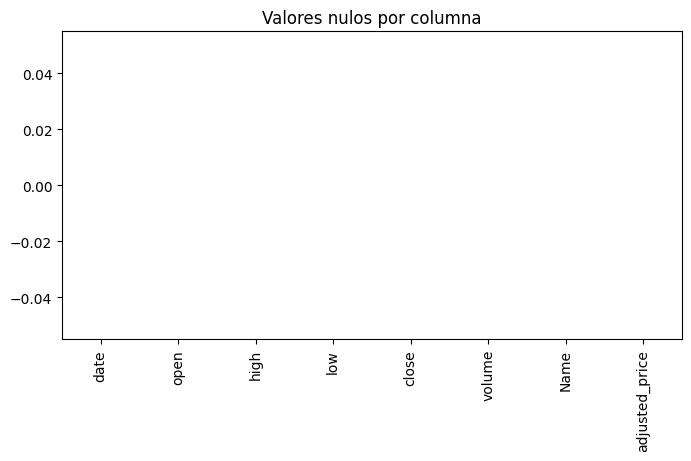

In [18]:
df_clean.isna().sum().plot(kind="bar", figsize=(8,4), title="Valores nulos por columna")

In [19]:
df_clean.head()

,date,open,high,low,close,volume,Name,adjusted_price
0,2013-02-08,45.07,45.35,45.0,45.08,1824755,A,28.883968
1,2013-02-11,45.17,45.18,44.45,44.6,2915405,A,28.576422
2,2013-02-12,44.81,44.95,44.5,44.62,2373731,A,28.589230
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,28.672525
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,28.563612


## Avoiding Survivor bias

To eliminate survivor bias, we first obtain all month-end constituent lists for the S&P 500 from January 2013 to December 2018. We consolidate these lists into a single binary matrix, indicating whether each stock is an index constituent in the subsequent month. In this way, we are able to approximately reproduce the S&P 500 composition at any point in time within this period. In a second step, for all stocks that have been constituents of the index at any time during this interval, we download daily total return indices covering the same time frame.

In [20]:
folder_path = r'../../../data/raw'
path_components = os.path.join(folder_path, 'S&P 500 Historical Components & Changes(01-17-2026).csv')
df_hist_comp = pd.read_csv(path_components)
df_hist_comp['date'] = pd.to_datetime(df_hist_comp['date'])

print(df_hist_comp.head())
print("...")
print(df_hist_comp.tail())

        date                                            tickers
0 1996-01-02  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
1 1996-01-03  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
2 1996-01-04  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
3 1996-01-10  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
4 1996-01-11  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
...
           date                                            tickers
2700 2025-11-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2701 2025-11-28  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2702 2025-12-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2703 2025-12-22  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2704 2026-01-14  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...


In [21]:
df_hist_comp.dtypes

date       datetime64[us]
tickers               str
dtype: object

**It is neccessary to know when the data starts and ends**

In [22]:
first_date = df_clean.iloc[0]['date']
print(first_date)

last_date = df_clean.iloc[-1]['date']
print(last_date)

2013-02-08 00:00:00
2018-02-07 00:00:00


**Creating pandas tables to see which companies were on S&P 500 at the end of the month**

In [23]:
# Filtrar por fechas
df_hist_comp = df_hist_comp[(df_hist_comp['date'] >= first_date) & (df_hist_comp['date'] <= last_date)].copy()

# Extraer año y mes
df_hist_comp['year'] = df_hist_comp['date'].dt.year
df_hist_comp['month'] = df_hist_comp['date'].dt.month

# Tomar último día de cada mes
df_month_end = df_hist_comp.groupby(['year', 'month']).tail(1)

# Eliminar la columna 'date'
df_month_end = df_month_end.drop(columns=['date'])

# Reordenar columnas para que year y month queden primero
cols = ['year', 'month'] + [c for c in df_month_end.columns if c not in ['year', 'month']]
df_month_end = df_month_end[cols]

df_month_end = df_month_end.reset_index(drop=True)

# Revisar resultado
print(df_month_end.head())
print("...")
print(df_month_end.tail())

   year  month                                            tickers
0  2013      2  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
1  2013      3  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
2  2013      4  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
3  2013      5  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
4  2013      6  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
...
    year  month                                            tickers
56  2017     10  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
57  2017     11  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
58  2017     12  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
59  2018      1  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
60  2018      2  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...


In [24]:
all_tickers = set()

for tickers_str in df_hist_comp['tickers']:
    for t in tickers_str.split(','):
        all_tickers.add(t.strip())
all_tickers = sorted(all_tickers)

ticker_dict = {ticker: idx for idx, ticker in enumerate(all_tickers)}


n_months = len(df_month_end)
n_tickers = len(all_tickers)

# matriz de ceros
binary_matrix = np.zeros((n_months, n_tickers), dtype=int)

for i, row in df_month_end.iterrows():
    tickers_in_row = row['tickers'].split(',')  # separa los tickers
    for t in tickers_in_row:
        t = t.strip()  # quitar espacios
        if t in ticker_dict:  # seguridad
            j = ticker_dict[t]  # columna correspondiente
            binary_matrix[i, j] = 1


binary_df = pd.DataFrame(binary_matrix, columns=all_tickers)
binary_df.insert(0, 'year', df_month_end['year'])
binary_df.insert(1, 'month', df_month_end['month'])

binary_df.head()

,year,month,A,AABA,AAL,AAP,AAPL,ABBV,ABC,ABT,...,XL,XLNX,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
0,2013,2,1,1,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
1,2013,3,1,1,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
2,2013,4,1,1,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
3,2013,5,1,1,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
4,2013,6,1,1,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


## Feature engineering

For this NN we will need to create time series dataset. This dataset will be the closed price day for the last 5 days. We will use 1000 rows. 70:30 for train and test, respectively.

In [25]:
training_days = 700
trading_days = 300


all_dates = sorted(df_clean['date'].unique())

study_period_days = training_days + trading_days + 5 #Need to add 5 so there are 5 days prior first day

start_idx = 0

period_dates = all_dates[start_idx:start_idx + study_period_days]


print(len(period_dates))

1005


This function is made so it search the companies that were on S&P500 the last month of the 1000 blocks day

In [26]:
def get_stocks_for_period(binary_df, last_train_date):
    year = last_train_date.year
    month = last_train_date.month
    
    row = binary_df[
        (binary_df['year'] == year) &
        (binary_df['month'] == month)
    ]
    
    if row.empty:
        return []
    
    tickers_series = row.drop(columns=['year', 'month']).iloc[0]
    tickers = tickers_series[tickers_series == 1].index.tolist()
    
    return tickers


We only want stocks who are on the last day of training on the previous the matrix 

In [27]:
train_end_date = period_dates[training_days - 1]

stocks = get_stocks_for_period(binary_df, train_end_date)

df_clean = df_clean[df_clean["Name"].isin(stocks)]

df_clean = df_clean[df_clean['date'].isin(period_dates)]

df_clean.shape

(434982, 8)

**Create time series using the last 5 days of the adjusted closed price**

In [28]:
df_time_series = df_clean.copy()

cols = ["open", "high", "low", "close", "volume", "adjusted_price"]

for i in range(1, 6):
    df_time_series[f'close_t-{i}'] = df_time_series['adjusted_price'].shift(i)

# Target = día actual (el "6to")
df_time_series['target'] = df_time_series['adjusted_price']

df_time_series = df_time_series.drop(cols, axis=1)

df_time_series = df_time_series.dropna()

df_time_series.head()

,date,Name,close_t-1,close_t-2,close_t-3,close_t-4,close_t-5,target
5,2013-02-15,A,28.563612,28.672525,28.589230,28.576422,28.883968,27.070713
6,2013-02-19,A,27.070713,28.563612,28.672525,28.589230,28.576422,27.557655
7,2013-02-20,A,27.557655,27.070713,28.563612,28.672525,28.589230,27.064302
8,2013-02-21,A,27.064302,27.557655,27.070713,28.563612,28.672525,26.673462
9,2013-02-22,A,26.673462,27.064302,27.557655,27.070713,28.563612,26.782379


In [29]:
df_time_series.shape

(434977, 8)

## Normalize data

In [30]:
df_time_series.to_csv("./ann_dataset.csv", index=False)